In [ ]:
%pip install numpy matplotlib seaborn
%pip install mne scipy jupyter
%pip install PyQt6
%pip install -U "pandas>=2.4"

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached pandas-3.0.3-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
Using cached pandas-3.0.3-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.3 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.3
    Uninstalling pandas-2.3.3:
      Successfully uninstalled pandas-2.3.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu13 26.4.0 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
cuxfilter-cu13 26.6.0 requires cudf-cu13==26.6.*, but you have cudf-cu13 26.4.0 which is incompatible.
cugraph-cu13 26.6.0 requires cudf-cu13==26.6.*, but you have cudf-cu13 26.4.

In [4]:
%pip install mne-qt-browser

  Using cached mne_qt_browser-0.7.5-py3-none-any.whl (76 kB)
  Using cached QtPy-2.4.3-py3-none-any.whl (95 kB)
  Using cached darkdetect-0.8.0-py3-none-any.whl (9.0 kB)
  Using cached pyqtgraph-0.14.0-py3-none-any.whl (1.9 MB)
  Using cached scooby-0.11.2-py3-none-any.whl (20 kB)
  Using cached QDarkStyle-3.2.3-py2.py3-none-any.whl (871 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
from glob import glob
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from mne.datasets import eegbci

mne.viz.set_browser_backend("qt")

Using qt as 2D backend.


## Data Exploration

In [6]:
# Code partially obtained from dataset documentation: https://data-brain-mind.github.io/tutorials/reading-observed-at-mindless-moments-roamm-a-simultaneous-eeg-and-eye-tracking-dataset-of-natural-reading-with-attention-annotations/
# define data root
# this is the path to the ROAMM folder on local machine
roamm_root = r"./data"
ml_data_root = os.path.join(roamm_root, 'subject_ml_data')

In [7]:
# Select one subject and run number to test with
subject_id = 'sub-10014'
subject_dir = os.path.join(ml_data_root, subject_id)
run_number = 1
df_run = pd.read_pickle(os.path.join(subject_dir, f'{subject_id}_task-ReMind_run-0{run_number}_mldata.pkl')) # Load that file sub-10014_task-ReMind_run-01_mldata.pkl
df_run_filtered = df_run[df_run.first_pass_reading==True] # Filter for only data points where the participant is actually reading the text (not reading instructions or performing a MW check)

# Channels to filter for later
EEG_cols = ['Fp1',  'AF7',  'AF3',  'F1',  'F3',  'F5',  'F7',  'FT7',  'FC5',  'FC3',  'FC1',  'C1',  'C3',  'C5',  'T7',  'TP7',  'CP5',  'CP3',  'CP1',  'P1',  'P3',  'P5',  'P7',  'P9',  'PO7',  'PO3',  'O1',  'Iz',  'Oz',  'POz',  'Pz',  'CPz',  'Fpz',  'Fp2',  'AF8',  'AF4',  'Afz',  'Fz',  'F2',  'F4',  'F6',  'F8',  'FT8',  'FC6',  'FC4',  'FC2',  'FCz',  'Cz',  'C2',  'C4',  'C6',  'T8',  'TP8',  'CP6',  'CP4',  'CP2',  'P2',  'P4',  'P6',  'P8',  'P10',  'PO8',  'PO4',  'O2']

# Relevant description columns
exp_cols = ['time','is_mw', 'mw_onset', 'mw_offset', 'mw_dur']

In [8]:
display(df_run_filtered[EEG_cols+exp_cols].head())
display([*df_run_filtered.columns])

,Fp1,AF7,AF3,F1,F3,F5,F7,FT7,FC5,FC3,...,P8,P10,PO8,PO4,O2,time,is_mw,mw_onset,mw_offset,mw_dur
3215,-0.000002,-0.000007,-2.762219e-06,-1.366753e-06,-3.544587e-06,-5.710371e-06,-0.000009,-0.000013,-5.512084e-06,6.606348e-08,...,7.604189e-06,1.439227e-06,0.000005,-0.000004,-7.747814e-09,12.558594,NaN,NaN,NaN,NaN
3216,0.000005,-0.000006,-4.557251e-07,-2.306849e-07,-2.173366e-06,-5.698028e-06,-0.000013,-0.000014,-5.766115e-06,4.249122e-07,...,6.511477e-06,4.469098e-07,0.000002,-0.000008,-2.466721e-06,12.562500,NaN,NaN,NaN,NaN
3217,0.000009,-0.000005,2.396208e-06,7.263480e-07,-5.885837e-07,-4.361071e-06,-0.000013,-0.000013,-4.966136e-06,1.551966e-06,...,4.068826e-06,1.992376e-06,0.000001,-0.000011,-5.045393e-06,12.566406,NaN,NaN,NaN,NaN
3218,0.000009,-0.000004,4.148712e-06,1.541235e-06,5.652375e-07,-2.124938e-06,-0.000008,-0.000010,-2.756835e-06,2.947916e-06,...,1.893334e-06,4.632399e-06,0.000001,-0.000011,-5.805439e-06,12.570312,NaN,NaN,NaN,NaN
3219,0.000003,-0.000003,3.684951e-06,1.815096e-06,3.723075e-07,1.241060e-07,-0.000002,-0.000004,2.838915e-07,3.356566e-06,...,2.588261e-07,5.186343e-06,0.000002,-0.000010,-4.797033e-06,12.574219,NaN,NaN,NaN,NaN


['Fp1',
 'AF7',
 'AF3',
 'F1',
 'F3',
 'F5',
 'F7',
 'FT7',
 'FC5',
 'FC3',
 'FC1',
 'C1',
 'C3',
 'C5',
 'T7',
 'TP7',
 'CP5',
 'CP3',
 'CP1',
 'P1',
 'P3',
 'P5',
 'P7',
 'P9',
 'PO7',
 'PO3',
 'O1',
 'Iz',
 'Oz',
 'POz',
 'Pz',
 'CPz',
 'Fpz',
 'Fp2',
 'AF8',
 'AF4',
 'Afz',
 'Fz',
 'F2',
 'F4',
 'F6',
 'F8',
 'FT8',
 'FC6',
 'FC4',
 'FC2',
 'FCz',
 'Cz',
 'C2',
 'C4',
 'C6',
 'T8',
 'TP8',
 'CP6',
 'CP4',
 'CP2',
 'P2',
 'P4',
 'P6',
 'P8',
 'P10',
 'PO8',
 'PO4',
 'O2',
 'time',
 'sfreq',
 'first_pass_reading',
 'page_num',
 'page_start',
 'page_end',
 'page_dur',
 'is_mw',
 'mw_onset',
 'mw_offset',
 'mw_dur',
 'run_num',
 'story_name',
 'is_fix',
 'fix_L_eye',
 'fix_L_tStart',
 'fix_L_tEnd',
 'fix_L_duration',
 'fix_L_xAvg',
 'fix_L_yAvg',
 'fix_L_pupilAvg',
 'fix_L_fixed_word',
 'fix_L_fixed_word_key',
 'fix_R_eye',
 'fix_R_tStart',
 'fix_R_tEnd',
 'fix_R_duration',
 'fix_R_xAvg',
 'fix_R_yAvg',
 'fix_R_pupilAvg',
 'fix_R_fixed_word',
 'fix_R_fixed_word_key',
 'is_blink',
 'bli

### Create MNE Array object

In [9]:

eeg_data = df_run_filtered[EEG_cols+exp_cols]
eeg_data["is_mw"] = eeg_data["is_mw"].replace(np.nan, False) # Replace NaN with False in the MW column

eeg_dataT = eeg_data.values.T  # Transpose to (n_channels, n_samples)

# Create channel information
n_channels = eeg_dataT.shape[0]
ch_names = eeg_data.columns.tolist()  # Or specify your channel names
ch_types = ['eeg'] * n_channels  # All channels are EEG

# Create info object
info = mne.create_info(ch_names=ch_names, 
                       sfreq=256,  # Replace with your sampling frequency in Hz
                       ch_types=ch_types)

# Create Raw object
raw = mne.io.RawArray(eeg_dataT, info)

# Set channel types for experiment details
raw.set_channel_types({
    'time': 'syst',
    'is_mw': 'stim',
    'mw_onset': 'stim',
    'mw_offset': 'stim',
    'mw_dur': 'stim'
})

# Detect events and convert to annotations
events = mne.find_events(raw, stim_channel="is_mw")
print(events)

annot_from_events = mne.annotations_from_events(
    events=events,
    event_desc={0: "noMW", 1:"MW"},
    sfreq=raw.info["sfreq"],
    orig_time=raw.info["meas_date"],
)

# Add annotations
raw.set_annotations(annot_from_events)

Creating RawArray with float64 data, n_channels=69, n_times=54052
    Range : 0 ... 54051 =      0.000 ...   211.137 secs
Ready.
Finding events on: is_mw
10 events found on stim channel is_mw
Event IDs: [1]
[[ 1579     0     1]
 [13411     0     1]
 [16198     0     1]
 [25146     0     1]
 [30758     0     1]
 [32620     0     1]
 [35858     0     1]
 [39343     0     1]
 [44624     0     1]
 [50447     0     1]]


/tmp/ipykernel_14526/724557917.py:20: RuntimeWarning: The unit for channel(s) time has changed from V to NA.
  raw.set_channel_types({


<RawArray | 69 x 54052 (211.1 s), ~28.5 MiB, data loaded>

In [12]:
eegbci.standardize(raw)
montage = mne.channels.make_standard_montage("biosemi64")
raw.set_montage(montage)

<RawArray | 69 x 54052 (211.1 s), ~28.5 MiB, data loaded>

### Make visualizations

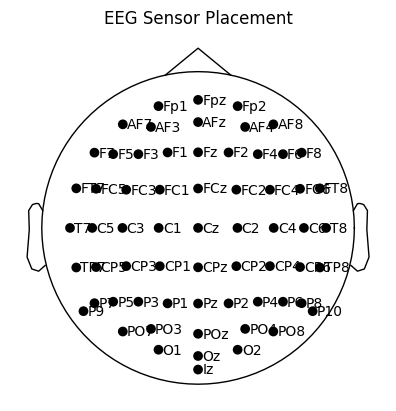

In [13]:
# EEG sensor placements
fig,ax = plt.subplots()
ax.set_title("EEG Sensor Placement")
raw.plot_sensors(show_names=True, axes=ax, kind='topomap', ch_type='eeg')
plt.show()

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/home/stefan/Documents/GitHub/BCI-Mind-Wandering/.conda/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


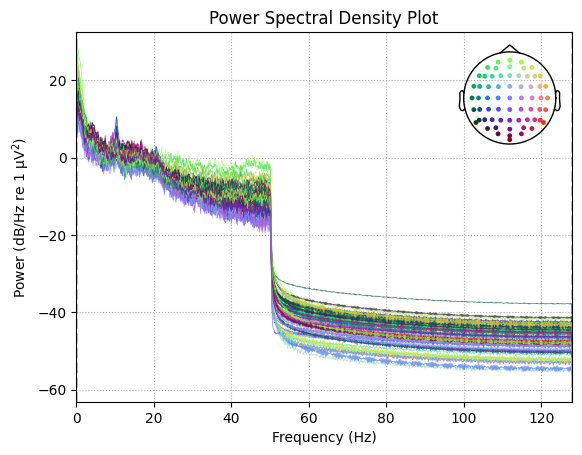

In [14]:
fig,ax = plt.subplots()
raw.compute_psd().plot(axes=ax)
ax.set_title("Power Spectral Density Plot")
plt.show()

Effective window size : 8.000 (s)


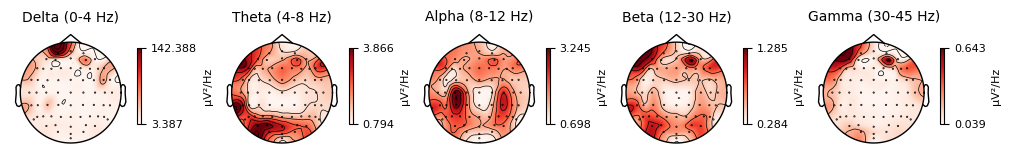

In [15]:
raw.compute_psd().plot_topomap()
plt.show()

## Full data pre-processing pipeline

In [2]:
def load_data(path):
    # Get subject ID
    subject_id = path.split("/")[-1][4:9]

    # Load file at path
    df_run = pd.read_pickle(path) # Load that file
    df_run_filtered = df_run # Filter for only data points where the participant is actually reading the text (not reading instructions or performing a MW check)

    eeg_data = df_run_filtered[EEG_cols]
    labels = df_run_filtered["is_mw"].replace(np.nan, False) # Replace NaN with False in the MW column

    eeg_dataT = eeg_data.values.T  # Transpose to (n_channels, n_samples)

    # Create channel information
    n_channels = eeg_dataT.shape[0]
    ch_names = eeg_data.columns.tolist()  # Or specify your channel names
    ch_types = ['eeg'] * n_channels  # All channels are EEG

    # Create info object
    info = mne.create_info(ch_names=ch_names, 
                        sfreq=256,
                        ch_types=ch_types)

    # Create Raw object
    eeg = mne.io.RawArray(eeg_dataT, info, verbose="WARNING")

    return subject_id, eeg, labels

In [ ]:
def preprocess_data(X_data, y, subject_id, window_size):
    """
    X_data: MNE object with EEG data as features
    y: binary mind wandering label
    subject_id: identifier for subject
    window_size: window size in ms
    """
    # New dataframe for labels and predictors
    df_out = pd.DataFrame(columns=["subject", "delta","theta","alpha", "beta", "gamma", "is_mw"])

    for i in range(0, len(X_data), int(window_size/2)): # This adds a 50% overlap between neighboring windows to prevent short mind wandering periods from being missed through majority voting
        psd = X_data.compute_psd(method="welch", verbose="WARNING", fmin=1.0, fmax=80.0, tmin=i/1000, tmax=(i+window_size)/1000)
        # display(psd.get_data(return_freqs=True))

        psds, freqs = psd.get_data(return_freqs=True)
        
        #This creates masks for certain frequency ranges
        delta_mask = (freqs >= 1.0) & (freqs < 4.0)
        theta_mask = (freqs >= 4.0) & (freqs < 8.0)
        alpha_mask = (freqs >= 8.0) & (freqs < 12.0)
        beta_mask  = (freqs >= 12.0) & (freqs < 30.0)
        gamma_mask = (freqs >= 30.0) & (freqs < 45.0)

        delta_power_per_channel = psds[:, delta_mask].mean(axis=1)
        theta_power_per_channel = psds[:, theta_mask].mean(axis=1)
        alpha_power_per_channel = psds[:, alpha_mask].mean(axis=1)
        beta_power_per_channel  = psds[:, beta_mask].mean(axis=1)
        gamma_power_per_channel  = psds[:, gamma_mask].mean(axis=1)

        # Set target label (mind wandering)
        label = y.iloc[i:(i+window_size)].median() # Majority vote regarding mind-wandering label

        # Save to new row
        if label == True or y.iloc[i:(i+window_size)].mean() < 0.1: #this should save only nonMW data that's got less than 10% MW in it
            df_out.loc[len(df_out)] = [
                subject_id,
                delta_power_per_channel,
                theta_power_per_channel,
                alpha_power_per_channel,
                beta_power_per_channel,
                gamma_power_per_channel,
                label
            ]

    # Fixing our mistakes
    df_processed = pd.DataFrame()
    df_processed["subject"] = df_out["subject"]
    df_processed["is_mw"] = df_out["is_mw"]

    for freq_band in freq_bands:
        df_processed[[freq_band+"_"+channel for channel in EEG_cols]] = pd.DataFrame(df_out[freq_band].tolist(), index=df_out.index)

    return df_processed

In [4]:
# Code partially obtained from dataset documentation: https://data-brain-mind.github.io/tutorials/reading-observed-at-mindless-moments-roamm-a-simultaneous-eeg-and-eye-tracking-dataset-of-natural-reading-with-attention-annotations/
# Define data root
roamm_root = r"./data"
ml_data_root = os.path.join(roamm_root, 'subject_ml_data')

# Channels to filter for later
EEG_cols = ['Fp1',  'AF7',  'AF3',  'F1',  'F3',  'F5',  'F7',  'FT7',  'FC5',  'FC3',  'FC1',  'C1',  'C3',  'C5',  'T7',  'TP7',  'CP5',  'CP3',  'CP1',  'P1',  'P3',  'P5',  'P7',  'P9',  'PO7',  'PO3',  'O1',  'Iz',  'Oz',  'POz',  'Pz',  'CPz',  'Fpz',  'Fp2',  'AF8',  'AF4',  'Afz',  'Fz',  'F2',  'F4',  'F6',  'F8',  'FT8',  'FC6',  'FC4',  'FC2',  'FCz',  'Cz',  'C2',  'C4',  'C6',  'T8',  'TP8',  'CP6',  'CP4',  'CP2',  'P2',  'P4',  'P6',  'P8',  'P10',  'PO8',  'PO4',  'O2']
freq_bands = ["delta", "theta","alpha", "beta", "gamma"]

# Parameters
window_size = 750

In [5]:
path = "data/subject_ml_data/sub-10014/sub-10014_task-ReMind_run-01_mldata.pkl"
# Load data
subject_id, eeg, labels = load_data(path)

# # Compute amplitude averages per frequency band per window
# psd = preprocess_data(eeg, labels, subject_id, window_size)

# psd.plot()

# psds, freqs = psd.get_data(return_freqs=True)
# # pd.DataFrame(psds[:,(freqs >= 1.0) & (freqs < 4.0)]).plot()
# # display(df_processed_subject)

In [6]:

for window_size in [2000]:#5000, 3000, 2000, 1000]:#, 500, 250]:
    df_processed = pd.DataFrame()

    # For debugging purposes
    invalid_files = []

    # File processing
    for path in glob(ml_data_root + "/*/*.pkl"):
        try:
            # Load data
            subject_id, eeg, labels = load_data(path)

            # Compute amplitude averages per frequency band per window
            df_processed_subject = preprocess_data(eeg, labels, subject_id, window_size)
            df_processed = pd.concat([df_processed, df_processed_subject], ignore_index=True)
        except:
            print("Failed to process:", path)
            invalid_files.append(path)

    # Filter extreme values
    df_filtered = df_processed.copy()
    for column in df_filtered.columns[2:]:
        upper = df_processed[column].mean() + 5 * df_processed[column].std()
        outliers = df_filtered[df_filtered[column] > upper]
        if (not outliers.empty):
            print(f"Removed the following {len(outliers)} rows as outliers in the {column} frequency band (> {upper:.3}). {outliers['is_mw'].mean()*100:.3}% MW")
            display(outliers)
        df_filtered = df_filtered[df_filtered[column] <= upper]

    # Z-score normalization separately for each frequency band (as value ranges between these bands vary)
    for freq_band in df_filtered.columns[2:]:
        df_filtered[freq_band] -= df_filtered[freq_band].mean() # Mean centering per band
        df_filtered[freq_band] /= df_filtered[freq_band].std() # Normalization for each band

    # Saving preprocessed data
    df_filtered.to_pickle(f"data/preprocessed/data_{window_size}ms.pkl")
    df_filtered.to_csv(f"data/preprocessed/data_{window_size}ms.csv")

    # Printing output
    display(df_filtered)
    if len(invalid_files) > 0:
        print("The following files could not be processed:")
        for file in invalid_files:
            print(f"- {file}")

Removed the following 5 rows as outliers in the theta frequency band (> 2.56e-11). 0.0% MW


,subject,delta,theta,alpha,beta,gamma,is_mw
20877,10073,4.959131e-10,3.323546e-11,1.050725e-11,2.213759e-12,4.303973e-13,0.0
20880,10073,1.064299e-09,7.180673e-11,3.036315e-11,9.194489e-12,1.044099e-12,0.0
20995,10073,5.929078e-09,1.011355e-09,1.023096e-10,2.284692e-11,3.365887e-12,0.0
24217,10165,2.221706e-10,3.905300e-11,9.662504e-12,1.857023e-12,4.873329e-13,0.0
38152,10148,7.258227e-12,3.281150e-11,5.146432e-12,6.889076e-13,8.108551e-14,0.0


Removed the following 217 rows as outliers in the alpha frequency band (> 6.46e-12). 2.3% MW


,subject,delta,theta,alpha,beta,gamma,is_mw
30,10173,2.136841e-12,2.660160e-12,8.673154e-12,4.675463e-13,1.042271e-13,0.0
32,10173,1.403392e-12,4.274024e-12,8.962733e-12,4.196382e-13,1.347907e-13,0.0
42,10173,1.246679e-12,1.332131e-12,7.356721e-12,4.914918e-13,1.285068e-13,0.0
43,10173,1.331340e-12,2.659111e-12,7.436084e-12,3.919099e-13,1.190188e-13,0.0
50,10173,1.432657e-12,3.497178e-12,1.218310e-11,4.566853e-13,1.226947e-13,0.0
...,...,...,...,...,...,...,...
42297,10197,1.961701e-12,1.891470e-12,7.126194e-12,1.803065e-13,5.481100e-14,0.0
42462,10197,2.682525e-12,8.193396e-13,7.701025e-12,2.099309e-13,7.972979e-14,0.0
42626,10197,1.272090e-12,4.523411e-13,7.270869e-12,2.901160e-13,8.679110e-14,0.0
42756,10197,1.661583e-12,9.175742e-13,7.914874e-12,3.109509e-13,7.175009e-14,0.0


Removed the following 53 rows as outliers in the beta frequency band (> 1.27e-12). 3.77% MW


,subject,delta,theta,alpha,beta,gamma,is_mw
353,10173,5.166217e-12,2.282157e-12,4.850716e-12,1.528843e-12,2.705529e-12,0.0
354,10173,5.285755e-12,1.251603e-12,2.320614e-12,2.130486e-12,2.688575e-12,0.0
541,10173,1.266576e-12,1.228721e-12,5.837015e-12,1.358855e-12,2.298456e-13,0.0
1128,10138,4.854207e-12,1.971988e-12,7.789037e-13,1.721782e-12,1.687422e-12,0.0
1129,10138,6.235123e-12,9.786948e-13,9.492851e-13,3.587303e-12,4.561498e-12,0.0
3790,10121,2.620473e-12,1.081546e-12,8.270759e-13,1.268439e-12,2.681842e-12,0.0
3791,10121,1.257620e-12,8.672260e-13,1.180579e-12,1.711126e-12,2.820715e-12,0.0
5714,10115,1.259653e-11,1.689823e-12,1.087293e-12,1.893267e-12,2.886933e-12,0.0
5715,10115,9.478891e-12,1.454884e-12,1.346264e-12,3.879491e-12,6.285289e-12,0.0
5737,10115,2.848156e-11,2.558692e-12,1.463241e-12,3.216176e-12,5.450912e-12,0.0


Removed the following 130 rows as outliers in the gamma frequency band (> 8.12e-13). 3.08% MW


,subject,delta,theta,alpha,beta,gamma,is_mw
289,10173,2.281479e-12,9.107515e-13,1.334669e-12,8.425780e-13,1.060798e-12,0.0
945,10138,6.809278e-12,1.716875e-12,8.449431e-13,7.724050e-13,8.447744e-13,0.0
1075,10138,2.004859e-12,1.655071e-12,3.632588e-13,5.038780e-13,9.053512e-13,0.0
1145,10138,2.276475e-12,1.646212e-12,8.887565e-13,7.427303e-13,1.137315e-12,0.0
2063,10195,5.535725e-12,1.376333e-12,1.261359e-12,1.142374e-12,1.577278e-12,0.0
...,...,...,...,...,...,...,...
44231,10110,4.406397e-12,1.686939e-12,1.396276e-12,9.748839e-13,8.132916e-13,0.0
44281,10110,9.930383e-12,2.334498e-12,2.198224e-12,9.207145e-13,1.200446e-12,0.0
44453,10110,2.247834e-11,4.549643e-12,2.126011e-12,9.633897e-13,1.009613e-12,0.0
44726,10110,5.964196e-12,1.630712e-12,9.612074e-13,6.939546e-13,1.148380e-12,0.0


,subject,delta,theta,alpha,beta,gamma,is_mw
0,10173,2.680831e-12,-0.387895,0.358505,1.034862,0.942734,-0.208918
1,10173,1.896106e-12,-0.392071,0.511299,1.543228,4.271154,-0.208918
2,10173,2.173003e-12,1.466031,1.948777,1.391203,1.903074,-0.208918
3,10173,1.801445e-12,-0.704909,-0.155691,0.754959,1.617793,-0.208918
4,10173,1.044729e-12,-0.352722,-0.247368,0.624889,0.454086,-0.208918
...,...,...,...,...,...,...,...
44802,10110,4.670635e-12,1.955783,0.027305,0.912103,0.667614,-0.208918
44803,10110,5.256711e-12,-0.165064,-0.150365,0.174658,0.641843,-0.208918
44804,10110,2.793995e-12,0.002937,0.298923,0.924879,0.872808,-0.208918
44805,10110,3.347516e-12,0.240340,0.572102,0.394825,0.376041,-0.208918


In [7]:
plt.bar(
    ["MW", "NoMW", "MW Window", "NoMW Window"],
    [
        labels.mean(),
        1-labels.mean(),
        df_filtered["is_mw"].mean(),
        1-(df_filtered["is_mw"].mean())
    ]
)

plt.title("Distribution of Class Labels")
plt.xlabel("Class")
plt.ylabel("Percentage of samples")

NameError: name 'labels' is not defined

In [ ]:
# Load data
path = "data/preprocessed_no_filter/data_channels_2000ms.pkl"
data = pd.read_pickle(path).reset_index(drop=True)
display(data.head())

# Split data
groups = data["subject"]
X = data[[*data.columns][2:]].astype(float)
y = data["is_mw"].astype(int)
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=20)

,subject,is_mw,delta_Fp1,delta_AF7,delta_AF3,delta_F1,delta_F3,delta_F5,delta_F7,delta_FT7,...,gamma_CP4,gamma_CP2,gamma_P2,gamma_P4,gamma_P6,gamma_P8,gamma_P10,gamma_PO8,gamma_PO4,gamma_O2
0,s10014,0.0,0.036392,0.806283,0.702137,2.611445,2.227172,-0.011721,-0.014614,0.072436,...,0.951696,1.389987,1.344207,0.676395,1.316434,1.836803,0.281054,-0.005183,0.067236,-0.111684
1,s10014,0.0,-0.057341,-0.023903,0.242599,0.497145,0.737509,-0.009780,-0.014312,-0.023222,...,0.652719,0.115159,0.229038,0.067341,-0.092901,0.018858,0.144775,-0.092135,-0.082410,-0.187698
2,s10014,0.0,0.093966,0.698166,0.474987,1.140857,1.341254,-0.004999,-0.013197,0.265089,...,2.295368,2.029761,3.588613,0.449112,0.440038,0.366018,1.409444,0.392718,0.478817,1.128086
3,s10014,0.0,-0.072759,-0.284230,-0.413816,-0.449349,-0.591286,-0.021513,-0.015498,-0.141696,...,1.427862,1.843583,0.382097,0.835554,0.574626,0.463631,0.542628,0.252162,-0.210987,0.207556
4,s10014,0.0,-0.009135,0.664665,-0.011975,1.034636,0.873698,-0.011056,-0.013197,0.229793,...,2.867416,1.905858,1.687344,1.297910,0.582020,0.258871,1.127615,0.149196,0.047951,0.458708


In [65]:
def train_logistic_regression(X, y, groups, parameters):
    cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=20)

    lr = LogisticRegression(random_state=20)
    clf = GridSearchCV(lr, parameters, cv=cv, scoring="roc_auc") 

    clf.fit(X,y,groups=groups)
    
    return clf

In [66]:
for fold, (train_idxs, test_idxs) in enumerate(cv.split(X, y, groups)):
    X_trainval, y_trainval = X.iloc[train_idxs].reset_index(drop=True), y[train_idxs].reset_index(drop=True)
    X_test, y_test = X.iloc[test_idxs].reset_index(drop=True), y[test_idxs].reset_index(drop=True)
    smote = SMOTE(sampling_strategy='minority', random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_trainval, y_trainval)

6251
11956


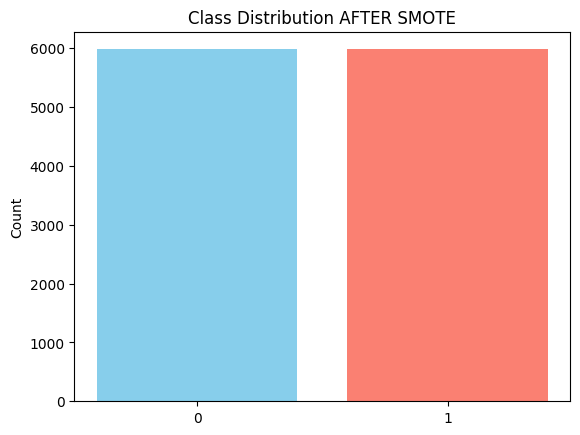

In [71]:
print(len(X_trainval))
print(len(X_train_sm))

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=['skyblue','salmon'])
plt.xticks([0,1])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

In [75]:
display(X_train_sm.tail())
X_trainval.tail()

,delta_Fp1,delta_AF7,delta_AF3,delta_F1,delta_F3,delta_F5,delta_F7,delta_FT7,delta_FC5,delta_FC3,...,gamma_CP4,gamma_CP2,gamma_P2,gamma_P4,gamma_P6,gamma_P8,gamma_P10,gamma_PO8,gamma_PO4,gamma_O2
11951,-0.027020,0.505214,0.068514,0.033710,0.724137,-0.000796,-0.013757,0.303909,0.606108,0.499952,...,0.153354,-0.488091,-0.404107,-0.024762,-0.109819,-0.273765,-0.433408,-0.221165,-0.283669,-0.312743
11952,-0.026731,-0.198430,0.385310,1.141552,1.224062,-0.013929,-0.015370,-0.182545,0.129559,2.499905,...,-0.725346,-0.953837,-0.638104,-0.672977,-0.573544,-0.249460,-0.419859,-0.232834,-0.450795,-0.396348
11953,-0.041306,-0.216724,0.005689,0.720344,0.408283,-0.012343,-0.013969,-0.004848,0.477588,0.147535,...,-0.870150,-0.895177,-0.793140,-0.981664,-0.648468,-0.287049,-0.524396,-0.314076,-0.662299,-0.457654
11954,-0.035448,-0.207895,0.160797,1.512468,1.097954,-0.016447,-0.014850,-0.007633,0.037222,0.429076,...,-0.390565,-0.519709,-0.787900,-0.879403,-0.625617,-0.355876,-0.296862,-0.272561,-0.626261,-0.314667
11955,0.052257,0.217021,0.055194,0.028391,-0.011398,-0.018726,-0.015288,-0.234487,-0.470978,-0.142145,...,-0.043844,-1.005452,-0.463313,-0.527968,-0.555189,-0.222144,-0.386264,-0.122803,-0.211780,0.025127


,delta_Fp1,delta_AF7,delta_AF3,delta_F1,delta_F3,delta_F5,delta_F7,delta_FT7,delta_FC5,delta_FC3,...,gamma_CP4,gamma_CP2,gamma_P2,gamma_P4,gamma_P6,gamma_P8,gamma_P10,gamma_PO8,gamma_PO4,gamma_O2
6246,-0.038798,-0.606480,-0.429851,-0.705677,-0.722884,-0.022807,-0.015879,-0.131287,-0.346348,-0.377987,...,-0.181814,-0.023013,0.603421,0.644668,0.486270,0.254498,0.411219,0.096847,0.293376,0.491546
6247,0.019751,-0.487602,0.083096,-0.590443,-0.471925,-0.019682,-0.015329,0.044684,-0.233725,-0.394939,...,-0.151422,-0.813470,0.220651,0.790186,0.703231,0.185223,0.241344,0.171864,0.301590,0.785365
6248,0.064053,-0.491687,1.451305,0.309187,0.237793,-0.022189,-0.016123,-0.296181,-0.714981,-0.068394,...,-0.288243,-0.072931,0.628221,0.145446,0.098646,0.041384,0.086954,0.065544,0.436375,0.655617
6249,0.049104,0.283567,1.118137,0.061075,0.485238,-0.016361,-0.015755,-0.139485,-0.030931,0.296129,...,0.094205,0.719584,1.271840,1.278398,0.666671,0.101056,-0.064942,0.188402,0.958043,0.765089
6250,-0.021230,-0.441000,0.208092,-0.256240,-0.174692,-0.021042,-0.015696,-0.228024,-0.360306,-0.173539,...,-0.128082,-0.466286,0.427071,0.262074,0.557048,0.072921,0.121235,0.069156,0.136039,0.585121
